# Содержание
- Инициализация проекта
- Исследование иходных данных
- Обработка пропущенных значений
- Обогащение данных
- Выбросы
- EDA
- Выводы
- Mindmap

# Инициализация проекта

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
original_df = pd.read_csv("../../data/predictive_maintenance_dataset.csv")
df = original_df.copy()

# Исследование исходных данных

Датасет содержит в себе следующие столбцы:  
- `UID` - Идентификатор, целое число от 1 до 10000
- `Product ID` - Идентификатор продукта, состоит из буквы обозначающей качество и номера
- `Type` - Качество продукта, категориальный признак
- `Air temperature` - Температура воздуха, непрерывный признак
- `Process temperature` - Температура процесса, непрерывный признак
- `Rotational speed` - Скорость вращения, целое число обозначающее число оборотов в минуту
- `Torque` - Крутящий момент, непрерывный признак
- `Tool wear` - Использование в минутах (износ)  

- `Machine failure` - Произошла ли поломка (0/1)  
#### Причины поломки:
- `TWF` - Отказ инструмента (инструмент заменяется или выходит из строя в случайно выбранный момент времени износа инструмента от 200 до 240 минут)
- `HDF` - Отказ теплоотвода (теплоотвод приводит к отказу процесса, если разница между температурой воздуха и рабочей температурой ниже 8,6 К, а скорость вращения инструмента ниже 1380 об/мин)
- `PWF` - Отказ по мощности (произведение крутящего момента и скорости вращения (в рад/с) равно мощности, необходимой для процесса. Если эта мощность ниже 3500 Вт или выше 9000 Вт, процесс выходит из строя)
- `OSF` - Отказ из-за перенапряжения (если произведение износа инструмента и крутящего момента превышает 11 000 минНм для варианта продукта L (12 000 M, 13 000 H), процесс завершается с ошибкой из-за перенапряжения)
- `RNF` - Случайный отказ (каждый процесс имеет вероятность поломки 0,1 % независимо от его параметров)  
  
В случае если произошла одна из поломок, то Machine failure = 1

In [3]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


### Определение числовых столбцов

In [4]:
columns = [
    "Air temperature [K]",
    "Process temperature [K]", 
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

In [5]:
df[columns].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


- `"Air temperature [K]" `: в среднем температура около 300К, очень маленькое стандартное отклонение 2К (значения плотно лежат около 300К), минимальная температура 295К, максимальная 304К.
- `Process temperature [K]`: в среднем температура процесса около 310К, стандартное отклонение 1.5К (значения плотно лежат около 310К), минимальная температура 305К, максимальная 313К.
- `Rotational speed [rpm]`: в сренем скорость вращения 1530 оборотов в минуту, сандартное отклонение также низкое что говориит о сгруппированости значений около 1530 оборотов в минуту, минимальное 1100, а максимальное  сильно далеко от среднего (2800).
- `Torque [Nm]`: крутящий момент, среднее 40, стандартное отклонение 10, значения умерено распределены около среднего, минимальное 3, максимальное 76, что соотносится со значениями скорости вращения.
- `Tool wear [min]`: время использования, среднее 100, стандартное отклонение 63, значения довольно широко распределены от среднего, минимальное 0, максимальное 253.

# Обработка пропущеных значений

In [6]:
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

UDI                        0.0
Product ID                 0.0
Type                       0.0
Air temperature [K]        0.0
Process temperature [K]    0.0
Rotational speed [rpm]     0.0
Torque [Nm]                0.0
Tool wear [min]            0.0
Machine failure            0.0
TWF                        0.0
HDF                        0.0
PWF                        0.0
OSF                        0.0
RNF                        0.0
dtype: float64

Пропущеных значений нет

# Корекция данных

In [7]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


Обезличивание

In [8]:
df = df.drop(columns=["Product ID", "UDI"])

Кодирование типов качества

In [9]:
df = pd.get_dummies(df, "Type", dtype=int)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Air temperature [K]      10000 non-null  float64
 1   Process temperature [K]  10000 non-null  float64
 2   Rotational speed [rpm]   10000 non-null  int64  
 3   Torque [Nm]              10000 non-null  float64
 4   Tool wear [min]          10000 non-null  int64  
 5   Machine failure          10000 non-null  int64  
 6   TWF                      10000 non-null  int64  
 7   HDF                      10000 non-null  int64  
 8   PWF                      10000 non-null  int64  
 9   OSF                      10000 non-null  int64  
 10  RNF                      10000 non-null  int64  
 11  Type_H                   10000 non-null  int64  
 12  Type_L                   10000 non-null  int64  
 13  Type_M                   10000 non-null  int64  
dtypes: float64(3), int64(11

Коррекция типов

Столбцы 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_H', 'Type_L', 'Type_M' стоит привести к типу int8 в целях этономии места

In [11]:
df[['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_H', 'Type_L', 'Type_M']] = df[['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_H', 'Type_L', 'Type_M']].astype('int8')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Air temperature [K]      10000 non-null  float64
 1   Process temperature [K]  10000 non-null  float64
 2   Rotational speed [rpm]   10000 non-null  int64  
 3   Torque [Nm]              10000 non-null  float64
 4   Tool wear [min]          10000 non-null  int64  
 5   Machine failure          10000 non-null  int8   
 6   TWF                      10000 non-null  int8   
 7   HDF                      10000 non-null  int8   
 8   PWF                      10000 non-null  int8   
 9   OSF                      10000 non-null  int8   
 10  RNF                      10000 non-null  int8   
 11  Type_H                   10000 non-null  int8   
 12  Type_L                   10000 non-null  int8   
 13  Type_M                   10000 non-null  int8   
dtypes: float64(3), int64(2)

По условию сказано, что если одна из категорий отказа принемает значение 1, то Machine failure тоже должне принимать значение 1, однако в датасете есть места где это не выполняется с категорией RNF.

In [13]:
df[df["RNF"] == 1]["Machine failure"]

1221    0
1302    0
1748    0
2072    0
2559    0
3065    0
3452    0
3611    1
5471    0
5489    0
5495    0
5509    0
5553    0
5639    0
6091    0
6913    0
6960    0
7488    0
7868    0
Name: Machine failure, dtype: int8

In [14]:
df.loc[df["RNF"] == 1, "Machine failure"] = 1

# Дубликаты

In [15]:
df.duplicated().sum()

np.int64(0)

# Выбросы

### Boxplot

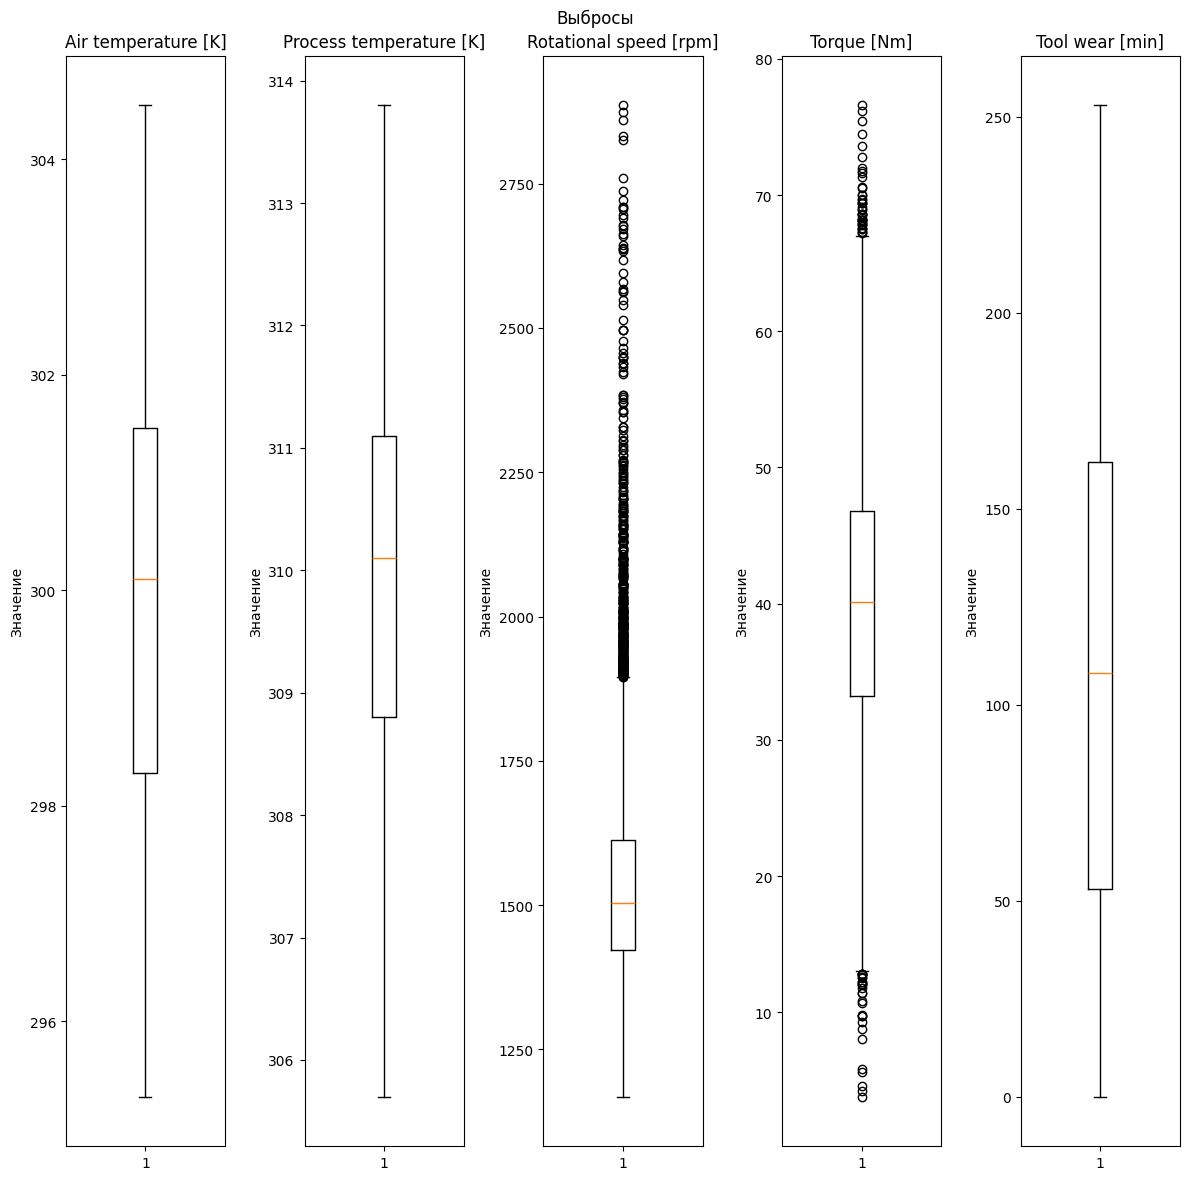

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(12, 12))
axes = axes.flatten()
for i, col in enumerate(columns):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
    axes[i].set_ylabel("Значение")

plt.suptitle("Выбросы")
plt.tight_layout()
plt.show()

### Анализ графиков

Столбцы с потенциальными выбросами:  
- `Rotational speed [rpm]`,
- `Torque [Nm]`

#### Анализ выбросов в столбце `"Rotational speed [rpm]"`

##### Отображение потенциадьных выбросов

In [17]:
df[df["Rotational speed [rpm]"] > 1900].sort_values(by="Rotational speed [rpm]", ascending=False)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
1784,298.3,308.0,2886,3.8,57,1,0,0,1,0,0,0,1,0
463,297.4,308.7,2874,4.2,118,1,0,0,1,0,0,0,1,0
50,298.9,309.1,2861,4.6,143,1,0,0,1,0,0,0,1,0
847,296.4,307.4,2833,5.6,213,1,0,0,1,0,0,0,1,0
4296,301.8,310.2,2825,5.8,215,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5248,303.5,313.0,1902,21.6,60,0,0,0,0,0,0,0,0,1
2058,299.5,309.3,1902,24.0,151,0,0,0,0,0,0,0,0,1
1888,297.8,307.4,1902,24.3,129,0,0,0,0,0,0,0,0,1
5183,303.9,313.0,1901,22.5,110,0,0,0,0,0,0,0,0,1


##### Проверка адекватности зависимых от скорости врещения значений

Первое, что стоит посмотреть это график значений скорости вращения и его зависимости с крутящим моментом, в случае не являющимся выбросом высокая скорость вращения будет влечь за собой уменьшение крутящего момента.

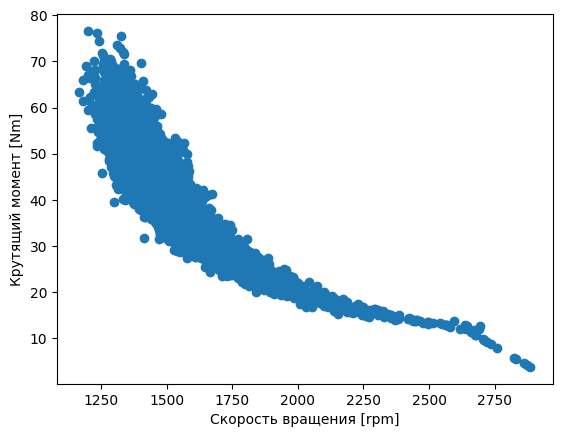

In [18]:
plt.scatter(df["Rotational speed [rpm]"], df["Torque [Nm]"])
plt.xlabel("Скорость вращения [rpm]")
plt.ylabel("Крутящий момент [Nm]")
plt.show()

На графике видно, что при аномально высоких значениях скорости вращения, крутящий момент принимает аномально низкие значения, что сходится с физикой и что говорит в пользу того, что это аномалия а не выброс.

##### Проверка класса устройств

Дополнительно посмотрим на класс устройств, для которых характерны аномалии

In [19]:
df[df["Rotational speed [rpm]"] > 1900][["Type_L", "Type_M", "Type_H"]].value_counts()

Type_L  Type_M  Type_H
1       0       0         249
0       1       0         124
        0       1          37
Name: count, dtype: int64

Исходя из таблицы видно что больше всего аномальных знчений скорости вращения характерно для устройств низкого и среднего класса, что тоже склоняет к аномальности а не к выбросам среди значений скорости вращения.

Исходя из этого, можно сделать вывод, о том что аномалные значения скорости вращения скорее всего авляются аномалиями

#### Анализ выбросов в столбце `"Torque [Nm]"`

In [20]:
low_torque = df[df["Torque [Nm]"] < 13]
high_torque = df[df["Torque [Nm]"] > 66]

extreme_torque = pd.concat([low_torque, high_torque], ignore_index=True)

In [21]:
extreme_torque

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
0,298.9,309.1,2861,4.6,143,1,0,0,1,0,0,0,1,0
1,298.2,308.5,2678,10.7,86,1,0,0,1,0,0,0,0,1
2,297.5,308.3,2564,12.8,127,1,0,0,1,0,0,0,1,0
3,297.4,308.7,2874,4.2,118,1,0,0,1,0,0,0,1,0
4,296.4,307.4,2833,5.6,213,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,298.7,310.1,1402,69.7,64,1,0,0,1,0,0,0,0,1
74,297.5,308.1,1334,72.0,151,1,0,0,1,0,0,0,0,1
75,297.2,307.9,1326,75.4,172,1,0,0,1,1,0,0,1,0
76,298.5,309.5,1294,66.7,12,1,0,0,1,0,0,0,1,0


##### Проверка адекватности зависимых от крутящего момента

График будет идентичен рассмотренному в анмализе скорости вращения, но с поменяными осями.

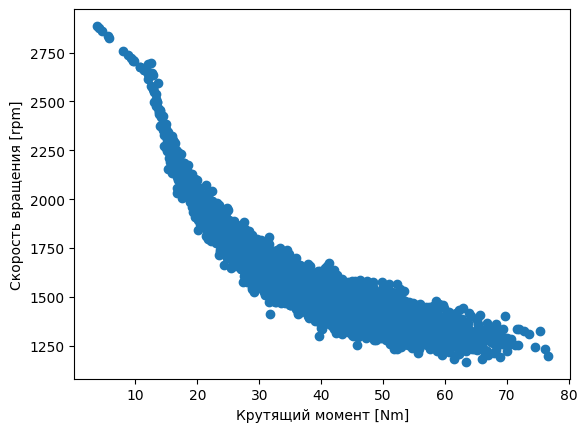

In [22]:
plt.scatter(df["Torque [Nm]"], df["Rotational speed [rpm]"])
plt.ylabel("Скорость вращения [rpm]")
plt.xlabel("Крутящий момент [Nm]")
plt.show()

На графике видно, что при аномально низких значениях крутящего момента, скорость вращения принимает аномально высокие значения значения, что сходится с физикой и что говорит в пользу того, что это аномалия а не выброс.

##### Проверка класса устройств

In [23]:
df[df["Torque [Nm]"] > 66][["Type_L", "Type_M", "Type_H"]].value_counts()

Type_L  Type_M  Type_H
1       0       0         34
0       1       0         13
        0       1          3
Name: count, dtype: int64

In [24]:
df[df["Torque [Nm]"] < 13][["Type_L", "Type_M", "Type_H"]].value_counts()

Type_L  Type_M  Type_H
1       0       0         17
0       1       0          9
        0       1          2
Name: count, dtype: int64

Исходя из таблицы видно что больше всего аномальных знчений крутящего момента характерно для устройств низкого и среднего класса, что тоже склоняет к аномальности а не к выбросам среди значений скорости вращения.

#### Выводы по потнециальным выбросам

Скорее всего потенциальные выбросы - аномалии и не требуют удаления

# Обогащение данными

#### Причины поломки:
- `TWF` - Отказ инструмента (инструмент заменяется или выходит из строя в случайно выбранный момент времени износа инструмента от 200 до 240 минут)
- `HDF` - Отказ теплоотвода (теплоотвод приводит к отказу процесса, если разница между температурой воздуха и рабочей температурой ниже 8,6 К, а скорость вращения инструмента ниже 1380 об/мин)
- `PWF` - Отказ по мощности (произведение крутящего момента и скорости вращения (в рад/с) равно мощности, необходимой для процесса. Если эта мощность ниже 3500 Вт или выше 9000 Вт, процесс выходит из строя)
- `OSF` - Отказ из-за перенапряжения (если произведение износа инструмента и крутящего момента превышает 11 000 минНм для варианта продукта L (12 000 M, 13 000 H), процесс завершается с ошибкой из-за перенапряжения)
- `RNF` - Случайный отказ (каждый процесс имеет вероятность поломки 0,1 % независимо от его параметров)  
  
Исходя из причин поломки стоит добавить столбцы: `модуль разности температур`, `rad/s`, `мощность`, `перегрузка`

In [25]:
df["Temp Abs"] = abs(df["Air temperature [K]"] - df["Process temperature [K]"])

In [26]:
df["rad/s"] = df["Rotational speed [rpm]"] * 2 * 3.14 / 60

In [27]:
df["Power"] = df["rad/s"] * df["Torque [Nm]"]

In [28]:
df["overload"] = df["Torque [Nm]"] * df["Tool wear [min]"]

Так-как все причины поломок описаны с конкретными границами, при выходе за которые происходит поломка, по имеет смысл добавить бинарные признаки
- `Critical temp diff and low rpm` - 1 при привышении нормы температур и недостаточной скорости вращения
- `Critical power value` - 1 при выходе значений Power из границ [3500, 9000]
- `Critical overload value` - 1 при переходе пороговых значений для кажого из типов качества продуктов


In [29]:
df["Critical temp diff and low rpm"] = ((df["Temp Abs"] < 8.6)  & (df["Rotational speed [rpm]"] < 1380)).astype(int)

In [30]:
df["Critical power value"] = ((df["Power"] <= 3500) | (df["Power"] >= 9000)).astype(int)

In [31]:
df["Critical overload value"] = (((df["Type_L"] == 1) & (df["overload"] > 11000)) | ((df["Type_M"] == 1) & (df["overload"] > 12000)) | ((df["Type_H"] == 1) & (df["overload"] > 13000))).astype(int)

Проверка на ненулевые

In [32]:
print(df["Critical temp diff and low rpm"].sum())
print(df["Critical power value"].sum())
print(df["Critical overload value"].sum())

115
94
98


# Нормализация данных

Определение столбцов к нормализации

In [33]:
columns = [
    "Air temperature [K]",
    "Process temperature [K]", 
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temp Abs",
    "rad/s",
    "Power",
    "overload"
]

In [34]:
df[columns]

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp Abs,rad/s,Power,overload
0,298.1,308.6,1551,42.8,0,10.5,162.338000,6948.066400,0.0
1,298.2,308.7,1408,46.3,3,10.5,147.370667,6823.261867,138.9
2,298.1,308.5,1498,49.4,5,10.4,156.790667,7745.458933,247.0
3,298.2,308.6,1433,39.5,7,10.4,149.987333,5924.499667,276.5
4,298.2,308.7,1408,40.0,9,10.5,147.370667,5894.826667,360.0
...,...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,9.6,167.885333,4952.617333,413.0
9996,298.9,308.4,1632,31.8,17,9.5,170.816000,5431.948800,540.6
9997,299.0,308.6,1645,33.4,22,9.6,172.176667,5750.700667,734.8
9998,299.0,308.7,1408,48.5,25,9.7,147.370667,7147.477333,1212.5


In [35]:
def minmax_norm(col):
    return (col - col.min()) / (col.max() - col.min())

for col in columns:
    df[f'norm_{col}'] = minmax_norm(df[col])

In [36]:
norm_columns = [f'norm_{col}' for col in columns]

# EDA

In [37]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,...,Critical overload value,norm_Air temperature [K],norm_Process temperature [K],norm_Rotational speed [rpm],norm_Torque [Nm],norm_Tool wear [min],norm_Temp Abs,norm_rad/s,norm_Power,norm_overload
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.03570,0.004600,0.011500,0.009500,0.009800,...,0.009800,0.511405,0.531551,0.215818,0.497073,0.426684,0.533473,0.215818,0.550482,0.261542
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.18555,0.067671,0.106625,0.097009,0.098514,...,0.098514,0.217419,0.183177,0.104356,0.136936,0.251597,0.222465,0.104356,0.114512,0.171338
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.326087,0.382716,0.148428,0.403846,0.209486,0.377778,0.148428,0.473395,0.119031
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.521739,0.543210,0.194994,0.498626,0.426877,0.488889,0.194994,0.549546,0.243253
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.673913,0.666667,0.258440,0.590659,0.640316,0.755556,0.258440,0.628072,0.380615
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Гистограммы числовых характеристик

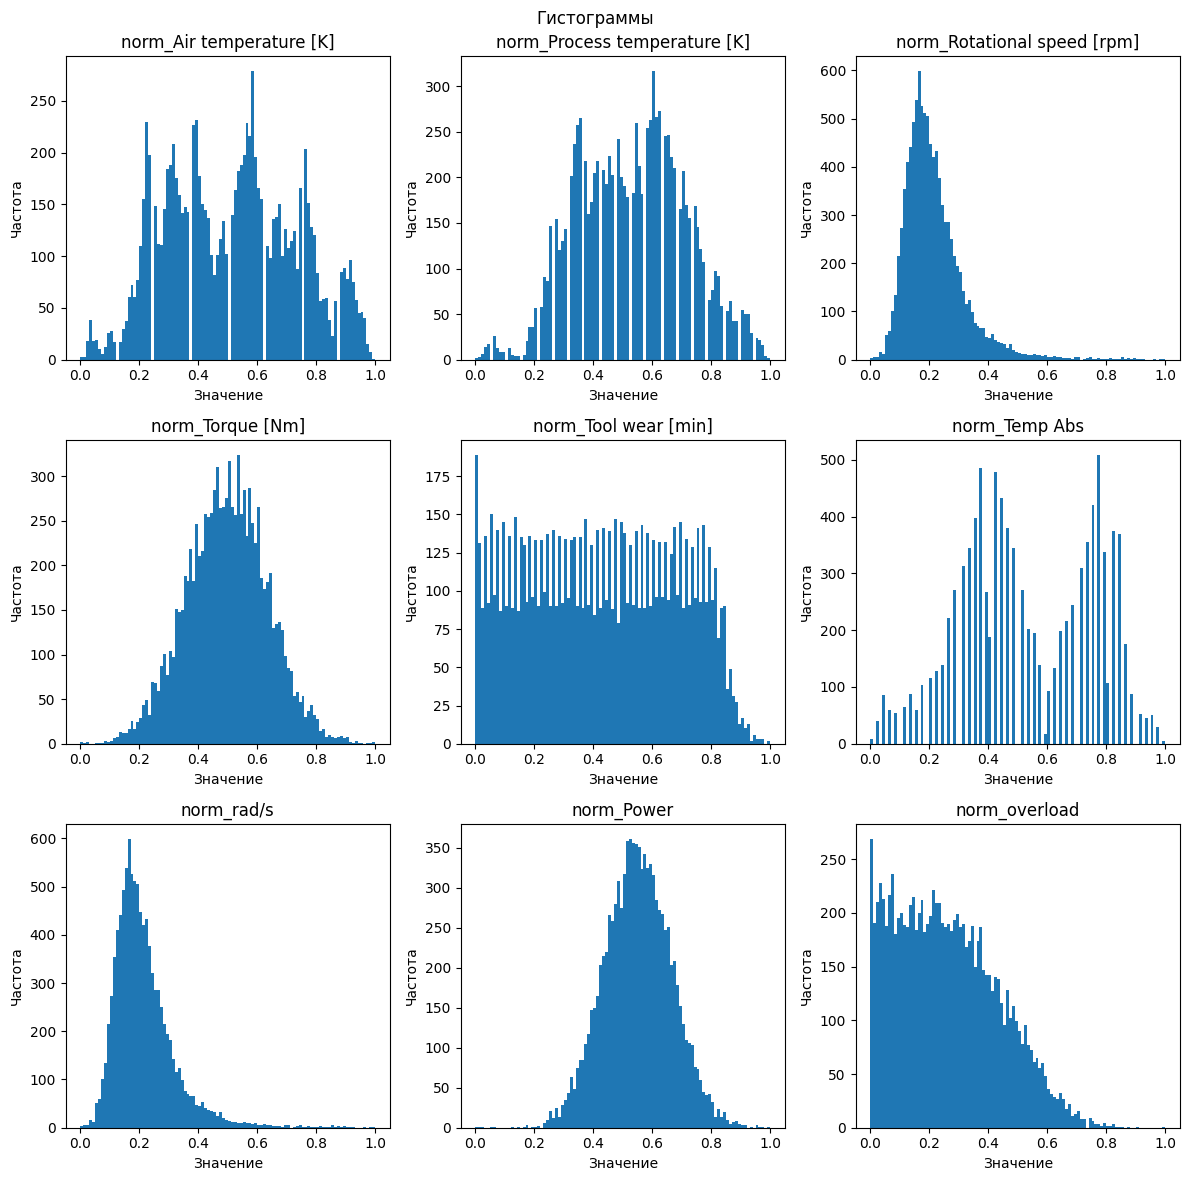

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
for i, col in enumerate(norm_columns):
    axes[i].hist(df[col], bins=100)
    axes[i].set_title(col)
    axes[i].set_xlabel("Значение")
    axes[i].set_ylabel("Частота")

plt.suptitle("Гистограммы")
plt.tight_layout()
plt.show()

- `air temperature` - темперапура воздуха довольно случайна

- `process temperature` - температура процесса также случайна

- `rotational speed` - логнормально распределено

- `torque` - имеет схожее распределение со скоростью вращения, т.к. физически от неё зависит

- `tool wear` - равноверно с резким падением, что говорит о, том что т.о. выполняется до поломки

- `temp abs` - вычисляется из air temperature и process temperature, подчеркивает два пика

- `rad/s` - линейно вычисляются из rotational speed - значит сохраняют околологнормальное распределение

- `power` вычисляется из rad/s и torque, что-то около нормального распределения

- `overload` вычисляется из tool wear и качества, распределние имеет схожую тенденцию как и износ

### Процент поломок

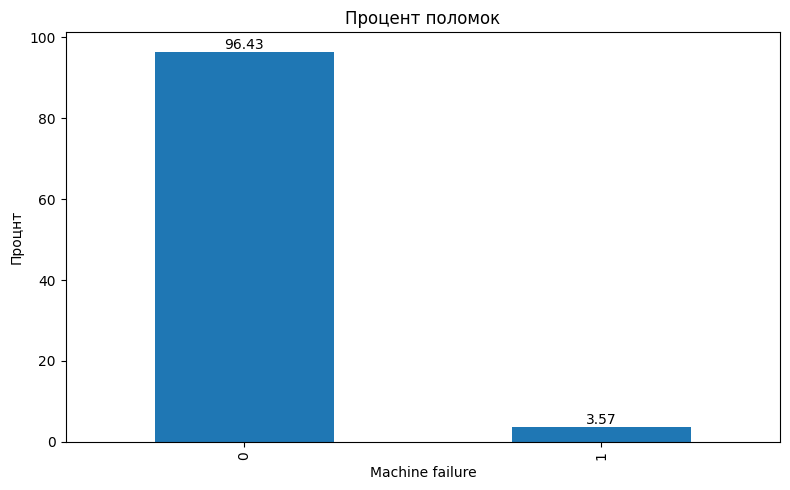

In [39]:
counts = df["Machine failure"].value_counts(normalize=True) * 100

ax = counts.plot(kind="bar", figsize=(8, 5))
plt.title(f"Процент поломок")
plt.ylabel("Процнт")

for bar in ax.containers:
    ax.bar_label(bar, fmt="%.2f")

plt.tight_layout()
plt.show()

Всего 3.4% процента пололмок, что свидедельствует о своевременном прохождении т.о..

### Процент категории из-за которых возникла поломка

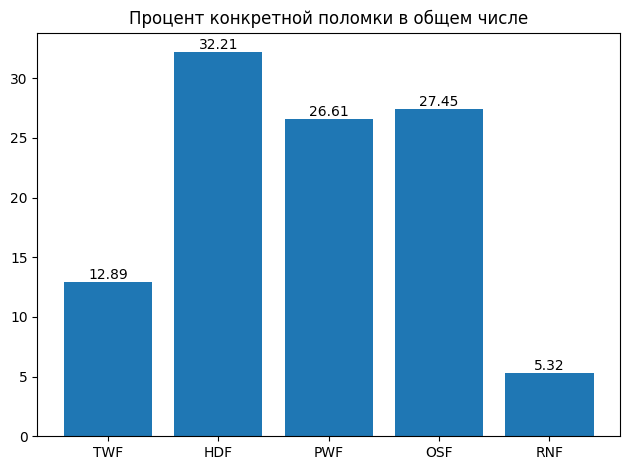

In [40]:
fail_categories = ["TWF", "HDF", "PWF", "OSF", "RNF"]
counts = [df[df["Machine failure"] == 1][cat].value_counts(normalize=True) * 100 for cat in fail_categories]
failure_pct = [round(cnt[1], 2) for cnt in counts]

fig, ax = plt.subplots()
bar = ax.bar(fail_categories, failure_pct)
ax.set_title("Процент конкретной поломки в общем числе")
ax.bar_label(bar, fmt="%.2f")

plt.tight_layout()
plt.show()

Отказ теплоотвода имеет самую высокую долю поломок, что может говорить о сильном влиянии температуры воздуха на поломку

### Корреляция

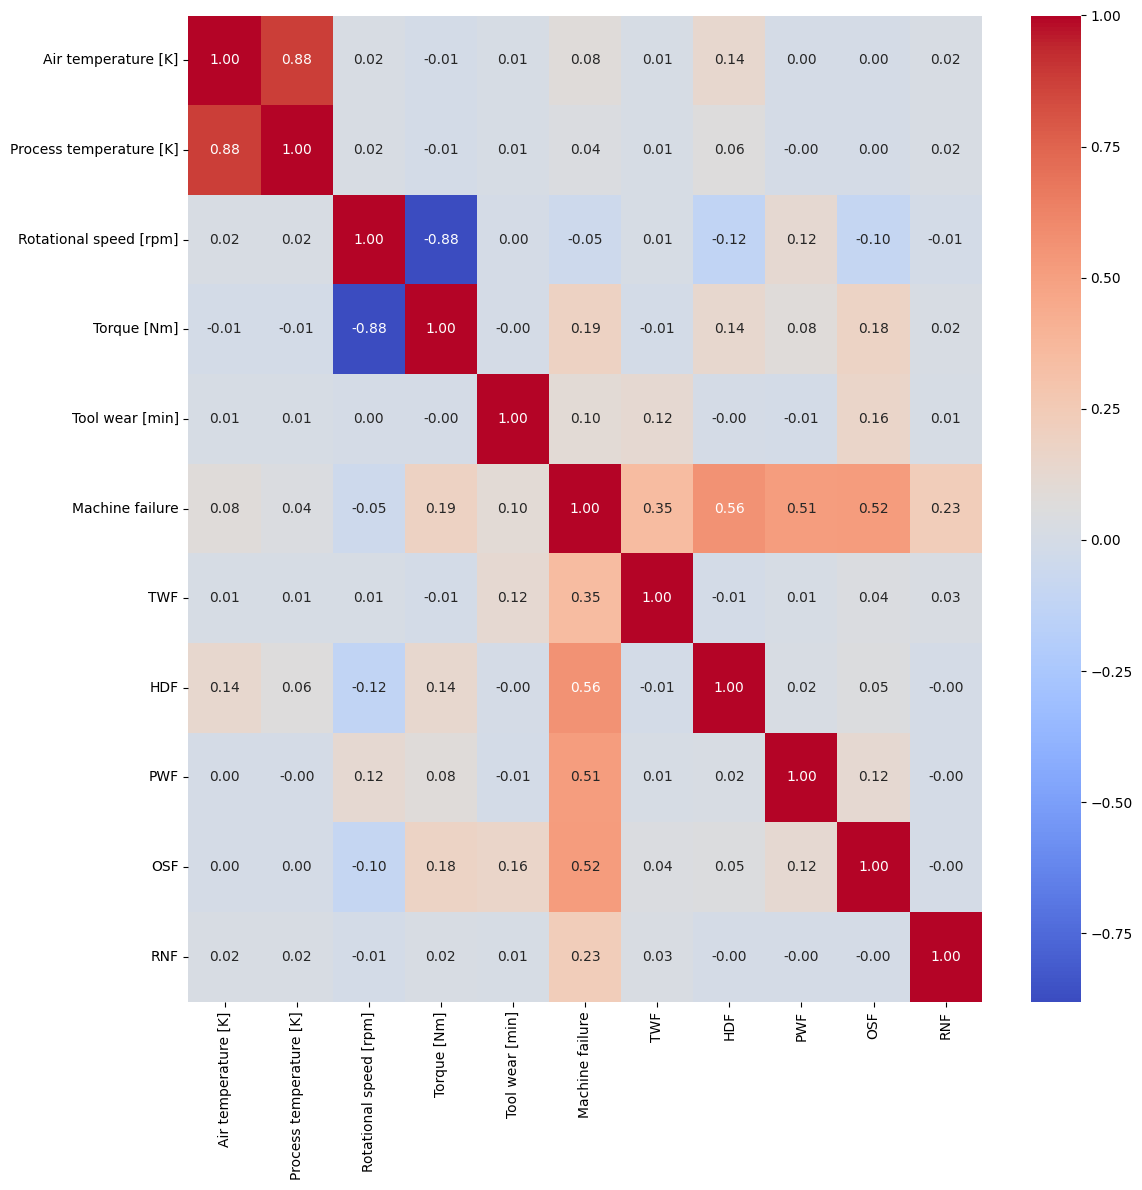

In [41]:
imp_cols = [
    "Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]", "Machine failure", 
    "TWF", "HDF", "PWF", "OSF", "RNF",
]
corr = df[imp_cols].corr()

fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(round(corr, 2), annot=True, ax=ax, cmap="coolwarm", fmt=".2f")
plt.tight_layout()
plt.show()

- Температура воздуха и процесса очень сильно положительно коррелируют, т.к. температура во вне будет охлаждать или повышать температуру внутри
- Крутящий момент и скорость вращения отрицательно коррелируют, что объяснимо физикой: чем выше скорость вращения, тем будет ниже крутящий момент
- Сильнее всего с целевой переменной коррелируют отказ теплоотвода и отказ из-за перегрузки, что говорит о сильном влияении температуры воздуха.

### Мощность

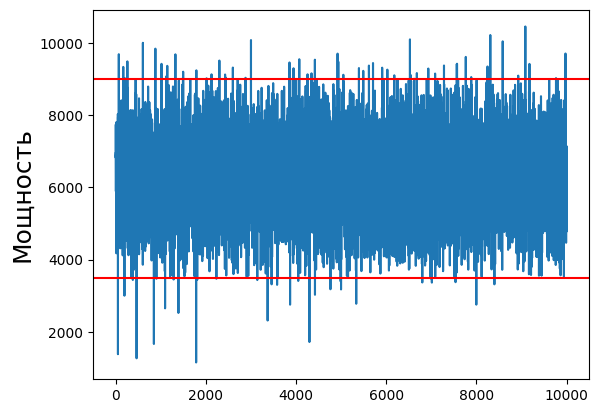

In [42]:
plt.plot(df["Power"])
plt.axhline(y=3500, color="red")
plt.axhline(y=9000, color="red")
plt.ylabel("Мощность",fontsize=18)
plt.show()

### Скорость вращения и разница температур

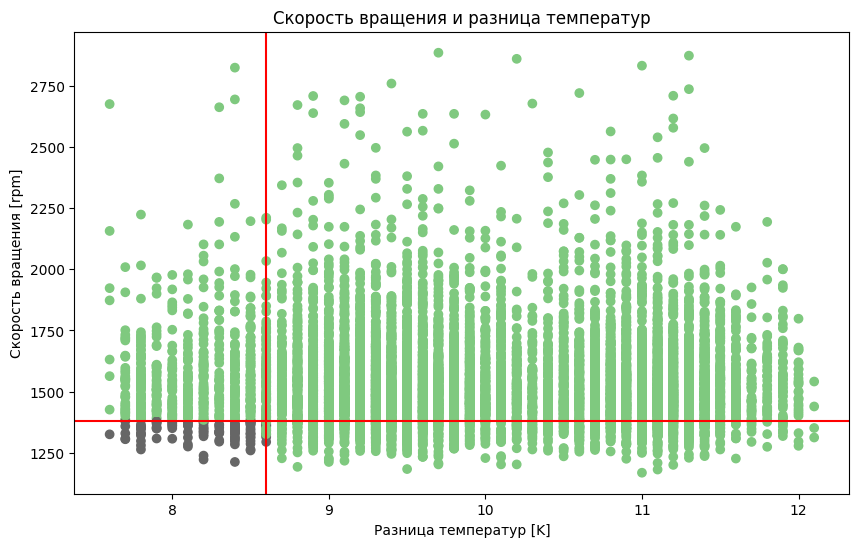

In [43]:
plt.figure(figsize=(10, 6))

plt.scatter(df["Temp Abs"], df["Rotational speed [rpm]"], c=df["Critical temp diff and low rpm"], cmap="Accent")
plt.axhline(y=1380, color="red")
plt.axvline(x=8.6, color="red")

plt.xlabel("Разница температур [K]")
plt.ylabel("Скорость вращения [rpm]")
plt.title("Скорость вращения и разница температур")

plt.show()

### Перегрузки по типам

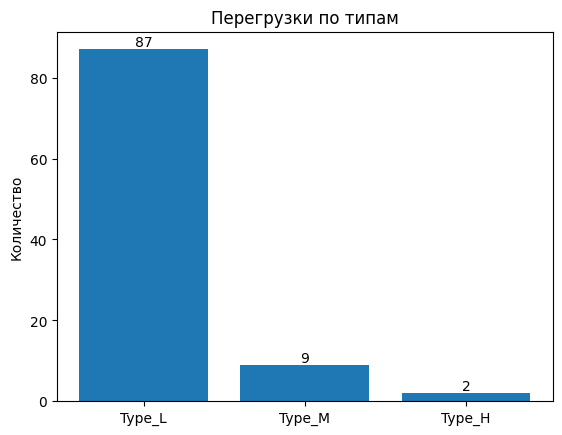

In [44]:
types = ["Type_L", "Type_M", "Type_H"]
steps = [11000, 12000, 13000]
counts = [((df[type_col] == 1) & (df["overload"] > step)).sum() for type_col, step in zip(types, steps)]

fig, ax = plt.subplots()
bar = ax.bar(types, counts)
plt.ylabel("Количество")
plt.title("Перегрузки по типам")
ax.bar_label(bar)
plt.show()

Продукты низкого качества чаще подвержены перегрузкам

# Сохранение датасета

Убрать ненормироанные столбцы

In [45]:
df = df.drop(columns=columns + ["Temp Abs", "rad/s", "Power", "overload", "Critical temp diff and low rpm", "Critical power value", "Critical overload value", "norm_Temp Abs", "norm_rad/s", "norm_Power", "norm_overload"])

In [46]:
df

,Machine failure,TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M,norm_Air temperature [K],norm_Process temperature [K],norm_Rotational speed [rpm],norm_Torque [Nm],norm_Tool wear [min]
0,0,0,0,0,0,0,0,0,1,0.304348,0.358025,0.222934,0.535714,0.000000
1,0,0,0,0,0,0,0,1,0,0.315217,0.370370,0.139697,0.583791,0.011858
2,0,0,0,0,0,0,0,1,0,0.304348,0.345679,0.192084,0.626374,0.019763
3,0,0,0,0,0,0,0,1,0,0.315217,0.358025,0.154249,0.490385,0.027668
4,0,0,0,0,0,0,0,1,0,0.315217,0.370370,0.139697,0.497253,0.035573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,1,0.380435,0.333333,0.253783,0.353022,0.055336
9996,0,0,0,0,0,0,1,0,0,0.391304,0.333333,0.270081,0.384615,0.067194
9997,0,0,0,0,0,0,0,0,1,0.402174,0.358025,0.277648,0.406593,0.086957
9998,0,0,0,0,0,0,1,0,0,0.402174,0.370370,0.139697,0.614011,0.098814


In [48]:
df.to_csv("../../data/predictive_maintenance_dataset_processed.csv", index=False)

# Выводы 

 Датасет содержит в себе информацию о статистике сенсоров продукта и его качестве, а также о причинах его поломки  
В датасете отсутствуют пропущенные значения  
Данные были обогащены вспомогательными значениями:  
- разница рабочей и окружающей температуры
- скорость вращения
- мощность
- перегрузка  
  
В датасете были выбросы с столбцах Rotational speed, Torque, rad/s, Power, overload, которые были минимизированны  
Гистограммы распределений числовх признаков показывают логарифмически нормальное распределение скорости вращения, нормальное распределение крутящего момента, некое сходство с равномерным распределением у износа  
Процент поломок около 3%  
Чаще всего поломка происходит из-за отказа теплоотвода  
- Температура воздуха и процесса очень сильно положительно коррелируют
- Крутящий момент и скорость вращения отрицательно коррелируют
- Сильнее всего с целевой переменной коррелируют отказ теплоотвода и отказ из-за перегрузки  
  
Продукты низкого качества чаще подвержены перегрузкам


# Mindmap  


![!\[maintaince_dataset_mindmap.png\](attachment:images/maintaince_dataset_mindmap.png)](../../images/maintaince_dataset_mindmap.png)